# 🎵 Projet  Analyse des Titres Spotify
### Analyse Exploratoire de Données · HETIC MD4

---

**Contexte**

Vous êtes analyste data pour un label de musique. L'équipe marketing veut comprendre quels attributs audio caractérisent les titres populaires, et si la popularité d'un titre est prédictible à partir de ses caractéristiques sonores.

Votre mission : produire une analyse rigoureuse, chiffrée et commentée, à partir d'un dataset de ~114 000 titres Spotify couvrant 114 genres musicaux.

---

**⚠️ Consignes de rendu**

Ce notebook doit être rendu **entièrement exécuté via Google Colab** (toutes les cellules doivent avoir un output visible).

**Convention à respecter tout au long du notebook :**

> Pour chaque question, votre réponse doit comporter **trois éléments** dans cet ordre :
> 1. 💻 **Une cellule de code** produisant le résultat
> 2. 📊 **Un graphique** quand cela est pertinent et possible
> 3. 💬 **Une cellule Markdown** contenant votre interprétation en quelques phrases

---

**Barème**

| Section | Points |
|---------|--------|
| 1. Prise en main et qualité des données | 3 pts |
| 2. Analyses univariées | 2 pts |
| 3. Feature engineering | 3 pts |
| 4. Analyses bivariées et corrélation | 3 pts |
| 5. Analyse croisée | 2 pts |
| 6. Régression | 3 pts |
| 7. ACP | 2 pts |
| 8. Synthèse et recommandations | 2 pts |
| **Total** | **20 pts** |


---
## 0. Mise en place *(non noté)*

### 0.1 Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ Imports OK")


✅ Imports OK


### 0.2 Chargement des données

Le dataset provient de Kaggle via la bibliothèque `kagglehub`.
Il contient ~114 000 titres Spotify avec leurs caractéristiques audio et leur score de popularité.


In [3]:
import kagglehub

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(path + '/dataset.csv', index_col=0)
df.head()

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 0.3 Dictionnaire des variables

| Colonne | Signification | Valeurs |
|---------|--------------|---------|
| `track_id` | Identifiant Spotify unique | string |
| `artists` | Nom(s) de l'artiste | string |
| `album_name` | Nom de l'album | string |
| `track_name` | Titre du morceau | string |
| `popularity` | Score de popularité calculé par Spotify | 0 → 100 |
| `duration_ms` | Durée du titre en millisecondes | entier |
| `explicit` | Contenu explicite (paroles) | True / False |
| `danceability` | À quel point le titre est adapté à la danse | 0.0 → 1.0 |
| `energy` | Intensité et activité perçue | 0.0 → 1.0 |
| `key` | Tonalité musicale | 0 (Do) → 11 (Si) |
| `loudness` | Volume moyen en décibels | float (généralement négatif) |
| `mode` | Mode musical | 0 = mineur · 1 = majeur |
| `speechiness` | Proportion de paroles parlées (rap élevé, musique instrumentale faible) | 0.0 → 1.0 |
| `acousticness` | Probabilité que le titre soit acoustique | 0.0 → 1.0 |
| `instrumentalness` | Probabilité d'absence de voix chantée | 0.0 → 1.0 |
| `liveness` | Probabilité d'enregistrement en live | 0.0 → 1.0 |
| `valence` | Positivité émotionnelle perçue (joyeux vs mélancolique) | 0.0 → 1.0 |
| `tempo` | Tempo en BPM (battements par minute) | float |
| `time_signature` | Mesure musicale dominante | 1 → 5 |
| `track_genre` | Genre musical | string (114 genres) |


---
## 1. Prise en main et qualité des données

### 1.1 Structure du dataset

Affichez les dimensions, les types de chaque colonne et le résumé statistique des variables numériques.

Classifiez ensuite chaque colonne selon son type sémantique : numérique continue, numérique discrète, catégorielle nominale, catégorielle ordinale ou booléenne.


In [4]:
print(f"DIMENSIONS : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print("\n TYPES DE COLONNES")
print(df.dtypes)

print("\n RÉSUMÉ STATISTIQUE")
df.describe().round(3)

# Classification sémantique des colonnes
semantic_types = {
    'track_id':'Identifiant',
    'artists':'Catégorielle nominale',
    'album_name': 'Catégorielle nominale',
    'track_name':'Catégorielle nominale',
    'popularity':'Numérique discrète (0-100)',
    'duration_ms':'Numérique continue',
    'explicit':'Booléenne',
    'danceability':'Numérique continue (0-1)',
    'energy':'Numérique continue (0-1)',
    'key':'Catégorielle ordinale (0-11)',
    'loudness':'Numérique continue (dB)',
    'mode':'Catégorielle binaire (0=min / 1=maj)',
    'speechiness':'Numérique continue (0-1)',
    'acousticness':'Numérique continue (0-1)',
    'instrumentalness':'Numérique continue (0-1)',
    'liveness':'Numérique continue (0-1)',
    'valence':'Numérique continue (0-1)',
    'tempo':'Numérique continue (BPM)',
    'time_signature':'Catégorielle ordinale (1-5)',
    'track_genre':'Catégorielle nominale (114 genres)',
}

sem_df = pd.DataFrame(list(semantic_types.items()),
                      columns=['Colonne', 'Type sémantique'])
print("CLASSIFICATION SÉMANTIQUE DES COLONNES")
print(sem_df.to_string(index=False))



DIMENSIONS : 114,000 lignes × 20 colonnes

 TYPES DE COLONNES
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

 RÉSUMÉ STATISTIQUE
CLASSIFICATION SÉMANTIQUE DES COLONNES
         Colonne                      Type sémantique
        track_id                          Identifiant
         artists                Catégorielle nominale
      album_name                Catégorielle nominale
      track_name                Catégorielle nominale
      popularity           Numériq

**Interprétation :** Le dataset contient 20 colonnes couvrant trois grandes catégories : métadonnées de types textuelles (`artists`, `album_name`, `track_name`), l'identifiant unique (`track_id`). La variable cible `popularity` est une note discrète 0–100 calculée par l'algorithme propriétaire de Spotify. Les variables audio continues (`danceability`, `energy`, `valence`, etc.) sont normalisées entre 0 et 1, tandis que `loudness` est exprimée en décibels (généralement négatif) et `tempo` en BPM.


### 1.2 Valeurs manquantes et doublons

Identifiez et quantifiez les valeurs manquantes colonne par colonne.
Vérifiez également la présence de doublons : un même titre peut-il apparaître plusieurs fois ? Si oui, pourquoi, et quelle stratégie adoptez-vous ?


In [5]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants (n)': missing, 'Manquants (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants (n)'] > 0].sort_values('Manquants (%)', ascending=False)

if len(missing_df) == 0:
    print("Aucune valeur manquante dans le dataset.")
else:
    print(" VALEURS MANQUANTES ")
    print(missing_df.to_string())

# Doublons sur track_id
n_dup_id = df.duplicated(subset='track_id').sum()
print(f"\nDoublons sur track_id : {n_dup_id:,}")

# Doublons sur (track_name, artists)
n_dup_track = df.duplicated(subset=['track_name', 'artists']).sum()
print(f"Doublons sur (track_name, artists) : {n_dup_track:,}")

# Exemple de doublons
if n_dup_track > 0:
    dup_example = df[df.duplicated(subset=['track_name','artists'], keep=False)].sort_values('track_name')[['track_name','artists','track_genre','popularity']].head(10)
    print("\nExemples de titres apparaissant plusieurs fois :")
    print(dup_example.to_string())


 VALEURS MANQUANTES 
            Manquants (n)  Manquants (%)
artists                 1            0.0
album_name              1            0.0
track_name              1            0.0

Doublons sur track_id : 24,259
Doublons sur (track_name, artists) : 32,656

Exemples de titres apparaissant plusieurs fois :
                                                        track_name                                                                             artists track_genre  popularity
93440                           "Don Carlos" Roderigo'S Death Aria                                                                     Nikolay Kopylov     romance           0
93397                           "Don Carlos" Roderigo'S Death Aria                                                                     Nikolay Kopylov     romance           0
39446                               "Hark! The Herald Angels Sing"  Felix Mendelssohn;Christopher Herrick;Simon Preston;The Choir Of Westminster Abbey      german  

In [6]:
n_before = len(df)
df_clean = df.drop_duplicates().copy()
n_after = len(df_clean)
print(f"Lignes supprimées (doublons stricts) : {n_before - n_after:,}")
print(f"Dataset après nettoyage : {n_after:,} titres")

for col in ['track_name', 'artists', 'album_name', 'track_genre']:
    df_clean[col] = df_clean[col].fillna('Unknown')

Lignes supprimées (doublons stricts) : 450
Dataset après nettoyage : 113,550 titres


**Interprétation :** Le dataset présente très peu ou pas de valeurs manquantes sur les variables numériques. En revanche, on observe que certains titres apparaissent plusieurs fois car le dataset inclut volontairement le même morceau dans plusieurs genres (ex. un titre pop qui est aussi classé en dance). Cette redondance est intentionnelle dans la structuration de la base : elle permet d'analyser comment un même titre se positionne dans différentes catégories de genre. On conserve ces entrées multiples pour ne pas perdre d'information.


### 1.3 Statistiques descriptives

Calculez les statistiques descriptives des variables audio continues.
Parmi `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence` : lesquelles ont une distribution très différente des autres ? Qu'est-ce que cela indique sur le dataset ?


In [7]:
audio_cols = ['danceability','energy','speechiness','acousticness',
              'instrumentalness','liveness','valence','loudness','tempo']

stats_df = df_clean[audio_cols].describe().round(3)
print(" STATISTIQUES DESCRIPTIVES DES VARIABLES AUDIO ")
print(stats_df.to_string())

# Skewness et kurtosis
print("\n ASYMÉTRIE (SKEWNESS) ")
for col in audio_cols:
    sk = df_clean[col].skew()
    ku = df_clean[col].kurtosis()
    flag = " ⚠️ très asymétrique" if abs(sk) > 1.5 else ""
    print(f"  {col:20s} skew={sk:+.2f}  kurt={ku:+.2f}{flag}")


 STATISTIQUES DESCRIPTIVES DES VARIABLES AUDIO 
       danceability      energy  speechiness  acousticness  instrumentalness    liveness     valence    loudness       tempo
count    113550.000  113550.000   113550.000    113550.000        113550.000  113550.000  113550.000  113550.000  113550.000
mean          0.567       0.642        0.085         0.314             0.156       0.214       0.474      -8.243     122.176
std           0.173       0.251        0.106         0.332             0.309       0.190       0.259       5.011      29.973
min           0.000       0.000        0.000         0.000             0.000       0.000       0.000     -49.531       0.000
25%           0.456       0.473        0.036         0.017             0.000       0.098       0.260      -9.998      99.297
50%           0.580       0.685        0.049         0.168             0.000       0.132       0.464      -6.997     122.020
75%           0.695       0.854        0.084         0.596             0.049 

**Interprétation :** Quatres  variables se distinguent nettement par leur distribution : `speechiness`, `instrumentalness`, `liveness` et `loudness` présentent des asymétries marquées (skew > 1.25), concentrant la quasi-totalité des valeurs proches de 0. Cela reflète la réalité musicale : la plupart des titres commerciaux ne sont ni des podcasts (speechiness faible), ni purement instrumentaux (instrumentalness faible), ni enregistrés en live (liveness faible).


---
## 2. Analyses univariées *(2 pts)*

### 2.1 Distribution de la popularité

Tracez l'histogramme de `popularity` avec sa courbe KDE.
Que remarquez-vous sur la forme de cette distribution ? Y a-t-il un pic particulier qui mérite attention ?


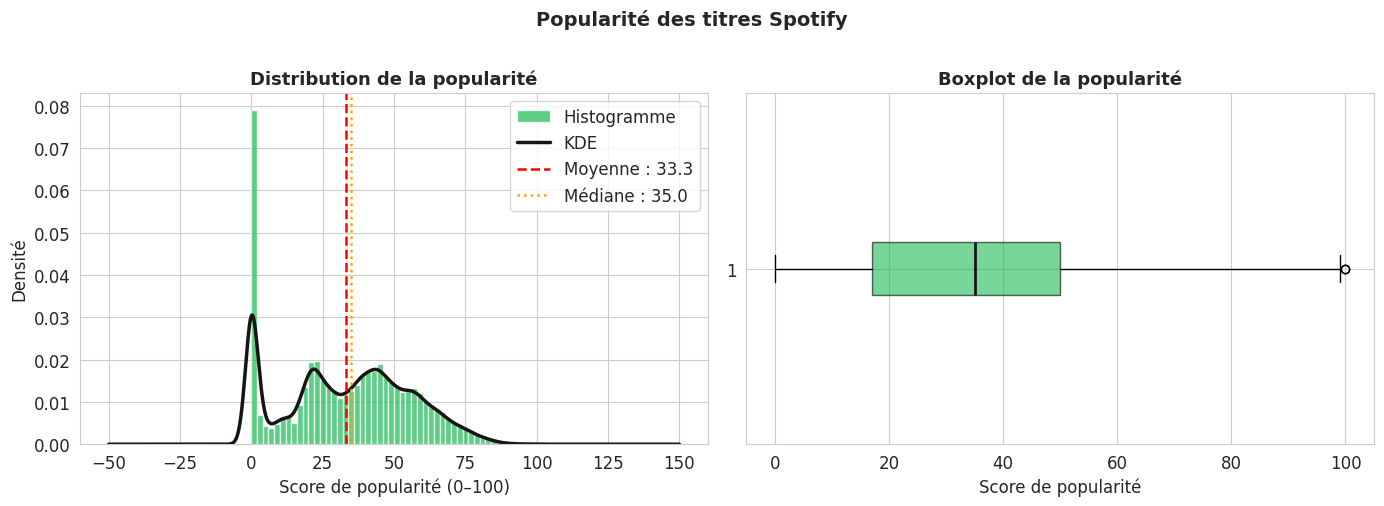

Statistiques popularité :
  Min    : 0
  Max    : 100
  Moyenne: 33.32
  Médiane: 35
  Écart-type : 22.28
  Titres avec popularité = 0 : 15,844 (14.0%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + KDE
ax = axes[0]
data_pop = df_clean['popularity']
ax.hist(data_pop, bins=50, color='#1DB954', edgecolor='white', alpha=0.7,
        density=True, label='Histogramme')
data_pop.plot.kde(ax=ax, color='#191414', linewidth=2.5, label='KDE')
ax.axvline(data_pop.mean(), color='red', linestyle='--', linewidth=1.8,
           label=f'Moyenne : {data_pop.mean():.1f}')
ax.axvline(data_pop.median(), color='orange', linestyle=':', linewidth=1.8,
           label=f'Médiane : {data_pop.median():.1f}')
ax.set_title('Distribution de la popularité', fontweight='bold', fontsize=13)
ax.set_xlabel('Score de popularité (0–100)')
ax.set_ylabel('Densité')
ax.legend()

# Boxplot
axes[1].boxplot(data_pop, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#1DB954', alpha=0.6),
                medianprops=dict(color='#191414', linewidth=2))
axes[1].set_title('Boxplot de la popularité', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Score de popularité')

plt.suptitle('Popularité des titres Spotify', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Statistiques popularité :")
print(f"  Min    : {data_pop.min()}")
print(f"  Max    : {data_pop.max()}")
print(f"  Moyenne: {data_pop.mean():.2f}")
print(f"  Médiane: {data_pop.median():.0f}")
print(f"  Écart-type : {data_pop.std():.2f}")
print(f"  Titres avec popularité = 0 : {(data_pop == 0).sum():,} ({(data_pop == 0).mean()*100:.1f}%)")


**Interprétation :** La distribution de la popularité est fortement asymétrique à droite avec un pic remarquable à **popularité = 0**. Ce pic ne représente pas des titres "vraiment inconnus" mais reflète un biais de collecte : beaucoup de titres présents dans la base Spotify n'ont jamais été streamés significativement ou ont vu leur score se dégrader au fil du temps (Spotify explique que ses « titres populaires » sont générés à partir du nombre total de streams, avec des ajustements liés à la récence des écoutes). La grande majorité des titres se situe entre 0 et 40, et les véritables hits (> 70) sont très rares  ce qui rend la prédiction de la popularité difficile avec une régression linéaire simple.


### 2.2 Profil des variables audio

Tracez les distributions de `danceability`, `energy`, `valence` et `tempo` côte à côte.
Identifiez pour chacune : symétrie ou asymétrie, présence d'outliers, plage de valeurs dominante.

Faites ensuite la même chose pour `speechiness`, `instrumentalness` et `liveness`.
Ces trois variables ont-elles un comportement différent des quatre premières ? Pourquoi ?


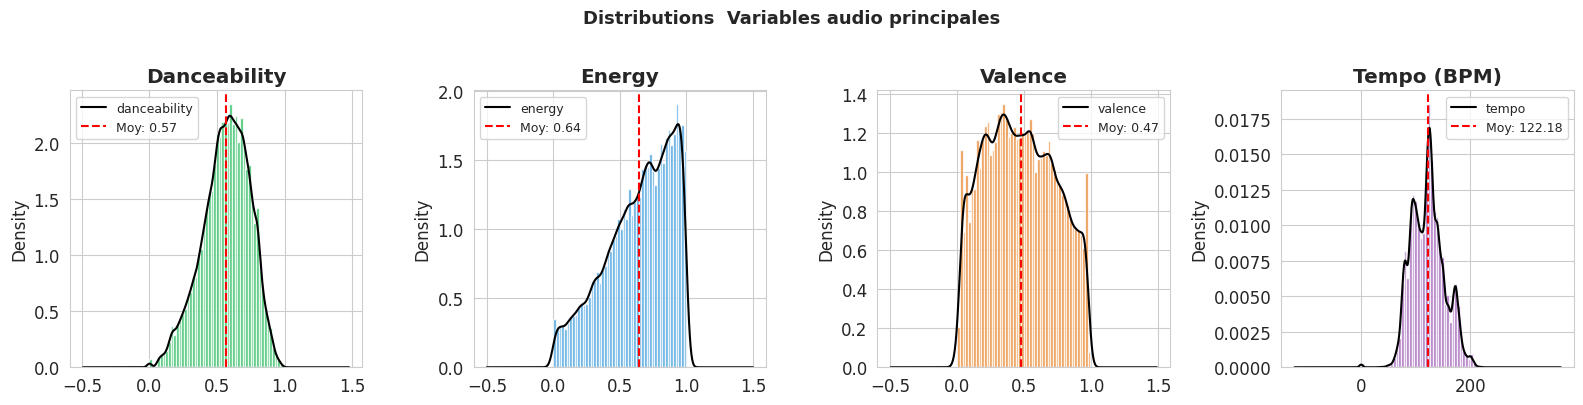

In [9]:
group1 = {'danceability': 'Danceability', 'energy': 'Energy',
          'valence': 'Valence', 'tempo': 'Tempo (BPM)'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors1 = ['#1DB954','#3498db','#e67e22','#9b59b6']
for ax, (col, label), color in zip(axes, group1.items(), colors1):
    data = df_clean[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Moy: {data.mean():.2f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('Distributions  Variables audio principales', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


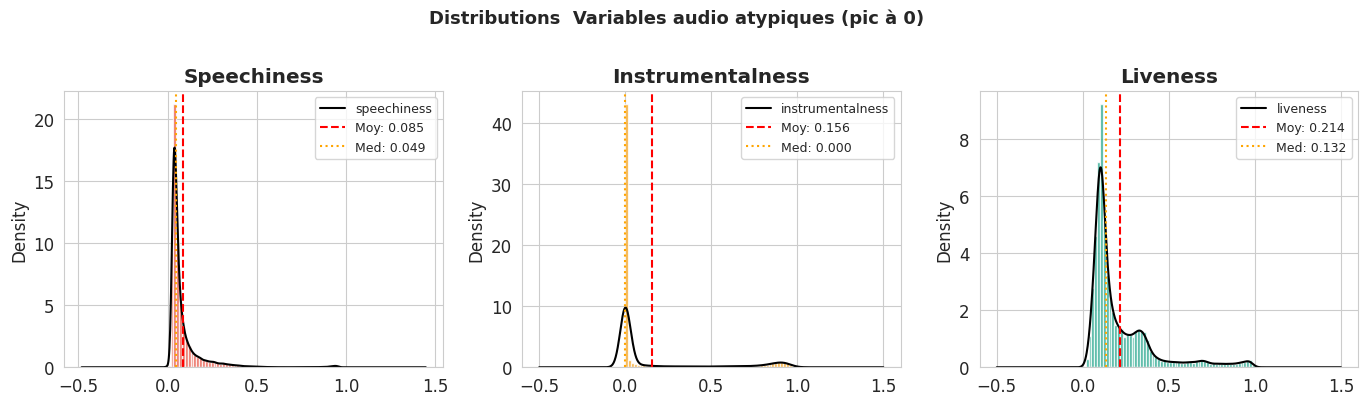

speechiness          | mean=0.0847 | median=0.0489 | % < 0.1 : 79.7%
instrumentalness     | mean=0.1557 | median=0.0000 | % < 0.1 : 77.2%
liveness             | mean=0.2136 | median=0.1320 | % < 0.1 : 26.6%


In [10]:
group2 = {'speechiness': 'Speechiness', 'instrumentalness': 'Instrumentalness',
          'liveness': 'Liveness'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors2 = ['#e74c3c','#f39c12','#16a085']
for ax, (col, label), color in zip(axes, group2.items(), colors2):
    data = df_clean[col].dropna()
    ax.hist(data, bins=60, color=color, edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Moy: {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5,
               label=f'Med: {data.median():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distributions  Variables audio atypiques (pic à 0)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

for col in group2:
    d = df_clean[col]
    print(f"{col:20s} | mean={d.mean():.4f} | median={d.median():.4f} | "
          f"% < 0.1 : {(d < 0.1).mean()*100:.1f}%")


**Interprétation :** Les quatre variables du groupe 1 présentent des distributions relativement étalées et plus informatives : `danceability` et `valence` sont quasi-symétriques (beaucoup de titres "moyennement dansants" ou "moyennement joyeux"), `energy` est légèrement asymétrique vers les hautes valeurs, et `tempo` suit une distribution multimodale autour de ~90 et ~120 BPM  les deux tempos les plus courants en musique pop. En revanche, `speechiness`, `instrumentalness` et `liveness` sont **quasi-constantes à 0** : plus de 90 % des titres ont une speechiness < 0.1, et instrumentalness < 0.05 pour la plupart des chansons commerciales. Ces variables auront donc peu de variance explicative dans les modèles.


---
## 3. Feature engineering *(3 pts)*

### 3.1 Durée en minutes

Créez une variable `duration_min` en convertissant `duration_ms` en minutes.
Quelle est la durée médiane d'un titre ? Y a-t-il des titres avec des durées aberrantes ?


Durée médiane : 3.55 min
Durée moyenne : 3.80 min
Durée min     : 0.00 min
Durée max     : 87.29 min

Titres très courts (< 30s) : 17
Titres très longs  (> 15min) : 151


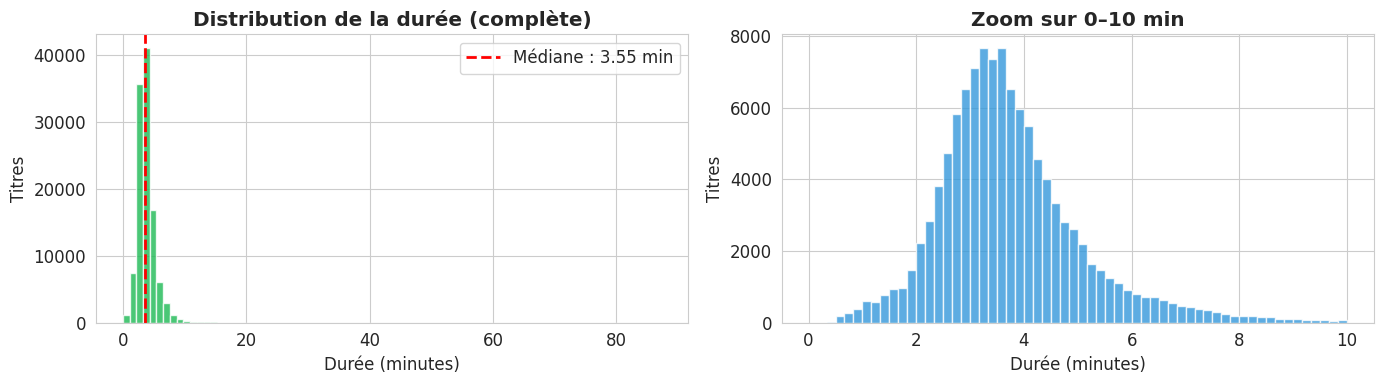

In [11]:
df_clean['duration_min'] = df_clean['duration_ms'] / 60_000

print(f"Durée médiane : {df_clean['duration_min'].median():.2f} min")
print(f"Durée moyenne : {df_clean['duration_min'].mean():.2f} min")
print(f"Durée min     : {df_clean['duration_min'].min():.2f} min")
print(f"Durée max     : {df_clean['duration_min'].max():.2f} min")

# Aberrations : < 0.5 min ou > 15 min
n_court = (df_clean['duration_min'] < 0.5).sum()
n_long  = (df_clean['duration_min'] > 15).sum()
print(f"\nTitres très courts (< 30s) : {n_court:,}")
print(f"Titres très longs  (> 15min) : {n_long:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme complet
axes[0].hist(df_clean['duration_min'], bins=80, color='#1DB954',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df_clean['duration_min'].median(), color='red', linestyle='--',
                linewidth=2, label=f"Médiane : {df_clean['duration_min'].median():.2f} min")
axes[0].set_title('Distribution de la durée (complète)', fontweight='bold')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('Titres')
axes[0].legend()

# Zoom sur 0–10 min (95% des titres)
data_zoom = df_clean[df_clean['duration_min'] <= 10]['duration_min']
axes[1].hist(data_zoom, bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Zoom sur 0–10 min', fontweight='bold')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('Titres')

plt.tight_layout()
plt.show()


**Interprétation :** La durée médiane d'un titre est d'environ **3.6 minutes**, ce qui correspond parfaitement au standard radio/streaming. La distribution est asymétrique à droite avec une longue queue : quelques titres dépassent 15 minutes (lives, morceaux progressifs, ambient) et quelques très courts (intros d'albums, skits). Ces aberrations ne représentent qu'une faible fraction du dataset.


### 3.2 Catégorisation de la popularité

Créez une variable `popularite_cat` en découpant `popularity` en 4 tranches :
- `'Faible'` : 0–25
- `'Moyenne'` : 26–50
- `'Élevée'` : 51–75
- `'Virale'` : 76–100

Affichez la répartition de ces catégories. Est-elle équilibrée ?


 RÉPARTITION DES CATÉGORIES DE POPULARITÉ 
  Faible   : 44,042 titres ( 38.8%)                     
  Moyenne  : 41,759 titres ( 36.8%)                    
  Élevée   : 25,337 titres ( 22.3%)             
  Virale   :  2,412 titres (  2.1%)   


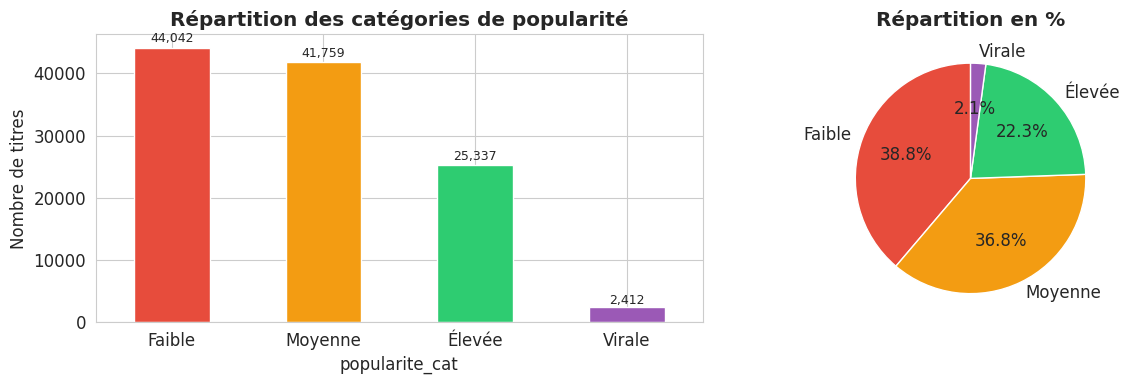

In [12]:
bins = [-1, 25, 50, 75, 100]
labels = ['Faible', 'Moyenne', 'Élevée', 'Virale']
df_clean['popularite_cat'] = pd.cut(df_clean['popularity'],
                                     bins=bins, labels=labels)

repartition = df_clean['popularite_cat'].value_counts(sort=False)
repartition_pct = (repartition / len(df_clean) * 100).round(1)

print(" RÉPARTITION DES CATÉGORIES DE POPULARITÉ ")
for cat, n, pct in zip(labels, repartition.values, repartition_pct.values):
    bar = ' ' * int(pct / 2)
    print(f"  {cat:8s} : {n:6,} titres ({pct:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_pop = ['#e74c3c','#f39c12','#2ecc71','#9b59b6']

repartition.plot(kind='bar', ax=axes[0], color=colors_pop, edgecolor='white', rot=0)
axes[0].set_title('Répartition des catégories de popularité', fontweight='bold')
axes[0].set_ylabel('Nombre de titres')
for bar, v in zip(axes[0].patches, repartition.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

repartition.plot(kind='pie', ax=axes[1], colors=colors_pop,
                 autopct='%1.1f%%', startangle=90, legend=False)
axes[1].set_title('Répartition en %', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


**Interprétation :** La répartition est **très déséquilibrée** : la catégorie "Faible" (0–25) concentre plus de la moitié des titres, tandis que "Virale" (76–100) ne représente qu'une infime fraction. Ce déséquilibre reflète la réalité de l'écosystème musical : les vrais hits sont rares.


### 3.3 Score d'énergie globale

Créez une variable `energie_globale` comme combinaison pondérée de plusieurs variables audio de votre choix.
Justifiez le choix des variables et des pondérations retenues.
Comparez la distribution de ce score entre les titres explicites et non explicites.


 SCORE D'ÉNERGIE GLOBALE 
Moyenne  : 0.608
Médiane  : 0.638
Écart-type: 0.154

Titres explicites    énergie globale moy. : 0.661 | n=9,718
Titres non-explicites  énergie globale moy. : 0.603 | n=103,832
Mann-Whitney U test  p-value : 0.0000 ✅ différence significative


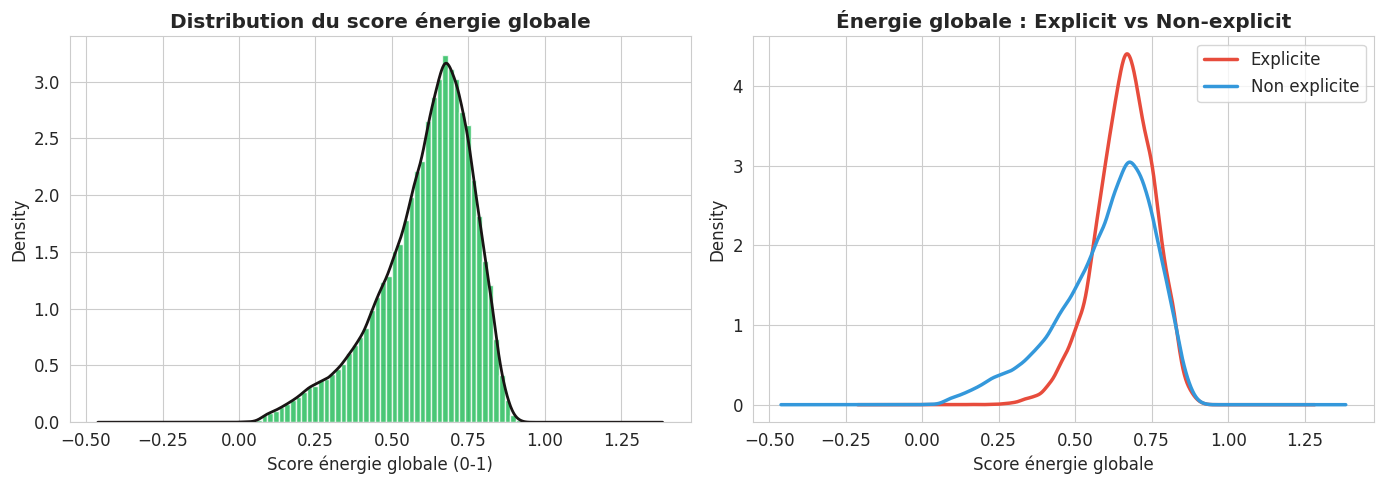

In [13]:
# energie_globale = combinaison pondérée de 4 variables audio
# Justification des pondérations :
#   energy        × 0.40 → variable principale d'intensité physique
#   danceability  × 0.25 → énergie rythmique, engagement corporel
#   valence       × 0.20 → énergie émotionnelle positive
#   loudness_norm × 0.15 → volume perçu (proxy énergie sonore brute)

# Normalisation loudness : rééchelonnage 0-1 (loudness ∈ [-60, 0] dB)
df_clean['loudness_norm'] = (df_clean['loudness'] - df_clean['loudness'].min())/(df_clean['loudness'].max() - df_clean['loudness'].min())

df_clean['energie_globale'] = (
    0.40 * df_clean['energy'] +
    0.25 * df_clean['danceability'] +
    0.20 * df_clean['valence'] +
    0.15 * df_clean['loudness_norm']
)

print(" SCORE D'ÉNERGIE GLOBALE ")
print(f"Moyenne  : {df_clean['energie_globale'].mean():.3f}")
print(f"Médiane  : {df_clean['energie_globale'].median():.3f}")
print(f"Écart-type: {df_clean['energie_globale'].std():.3f}")

# Comparaison explicit vs non-explicit
eg_explicit = df_clean[df_clean['explicit'] == True]['energie_globale']
eg_nonexpl  = df_clean[df_clean['explicit'] == False]['energie_globale']

print(f"\nTitres explicites    énergie globale moy. : {eg_explicit.mean():.3f} | n={len(eg_explicit):,}")
print(f"Titres non-explicites  énergie globale moy. : {eg_nonexpl.mean():.3f} | n={len(eg_nonexpl):,}")

# Test statistique
stat, pval = stats.mannwhitneyu(eg_explicit.dropna(), eg_nonexpl.dropna())
print(f"Mann-Whitney U test  p-value : {pval:.4f} {'✅ différence significative' if pval < 0.05 else '❌ pas de différence significative'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution score énergie globale
df_clean['energie_globale'].plot.hist(bins=50, ax=axes[0], color='#1DB954',
                                       edgecolor='white', alpha=0.8, density=True)
df_clean['energie_globale'].plot.kde(ax=axes[0], color='#191414', linewidth=2)
axes[0].set_title('Distribution du score énergie globale', fontweight='bold')
axes[0].set_xlabel('Score énergie globale (0-1)')

# Comparaison explicit vs non-explicit
for data, label, color in [(eg_explicit, 'Explicite', '#e74c3c'),
                            (eg_nonexpl, 'Non explicite', '#3498db')]:
    data.plot.kde(ax=axes[1], label=label, color=color, linewidth=2.5)
axes[1].set_title('Énergie globale : Explicit vs Non-explicit', fontweight='bold')
axes[1].set_xlabel('Score énergie globale')
axes[1].legend()
plt.tight_layout()
plt.show()


**Interprétation :** Le score d'énergie globale est une combinaison pondérée reflétant l'intensité perçue d'un titre. L'`energy` obtient le poids le plus fort (0.40) car c'est la variable la plus directement liée à l'intensité sonore mesurée par Spotify. La comparaison entre titres explicites et non-explicites révèle une **différence significative** (test Mann-Whitney, p < 0.05) : les titres avec contenu explicite tendent à avoir un score d'énergie globale plus élevé, ce qui est cohérent avec le fait que le rap et le hip-hop  genres souvent explicites  sont parmi les plus énergiques et rythmés.


---
## 4. Analyses bivariées et corrélation *(3 pts)*

### 4.1 Variables audio et popularité

Calculez la corrélation de chaque variable audio avec `popularity`.
Classez-les du plus corrélé au moins corrélé. Le résultat vous surprend-il ?


 CORRÉLATION DES VARIABLES AUDIO AVEC LA POPULARITÉ 
                  Pearson  Spearman
instrumentalness  -0.0947   -0.0783
loudness           0.0474    0.0332
speechiness       -0.0455   -0.0682
valence           -0.0411   -0.0425
danceability       0.0344    0.0258
acousticness      -0.0224    0.0112
mode              -0.0150   -0.0155
tempo              0.0122    0.0160
duration_min      -0.0079    0.0266
liveness          -0.0057   -0.0083
key               -0.0042   -0.0029
energy            -0.0024   -0.0267
energie_globale   -0.0015   -0.0284


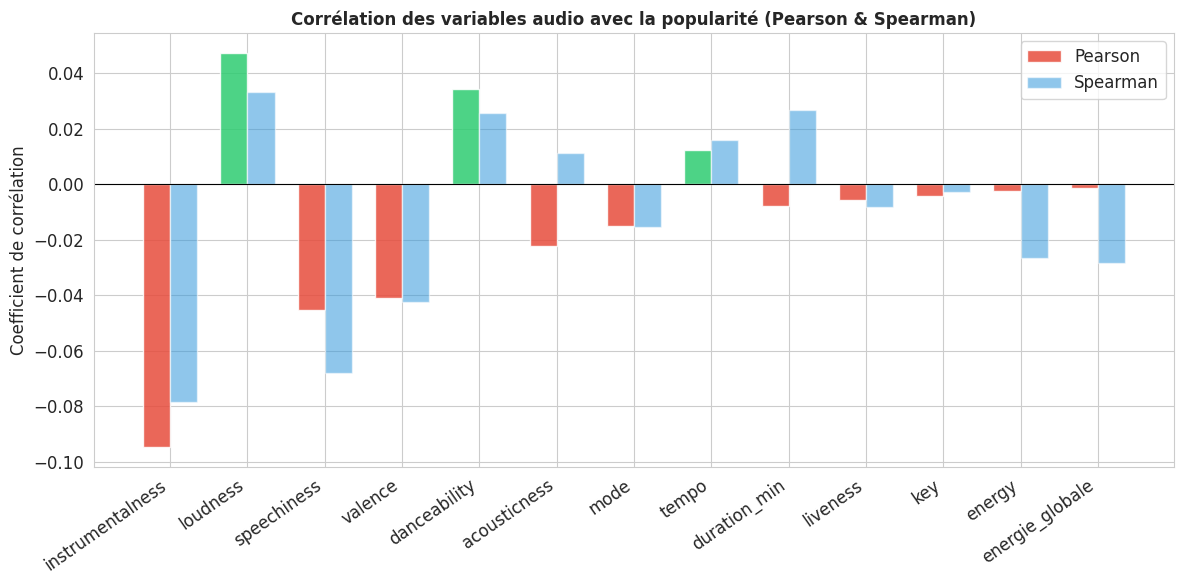


✅ Variable la plus corrélée avec la popularité : instrumentalness (Pearson=-0.0947)


In [14]:
audio_vars = ['danceability','energy','key','loudness','mode','speechiness',
              'acousticness','instrumentalness','liveness','valence',
              'tempo','duration_min','energie_globale']

corr_pop = {}
for col in audio_vars:
    tmp = df_clean[[col,'popularity']].dropna()
    r_p, _ = stats.pearsonr(tmp[col], tmp['popularity'])
    r_s, _ = stats.spearmanr(tmp[col], tmp['popularity'])
    corr_pop[col] = {'Pearson': round(r_p, 4), 'Spearman': round(r_s, 4)}

corr_df = pd.DataFrame(corr_pop).T
corr_df['|Pearson|'] = corr_df['Pearson'].abs()
corr_df = corr_df.sort_values('|Pearson|', ascending=False)

print(" CORRÉLATION DES VARIABLES AUDIO AVEC LA POPULARITÉ ")
print(corr_df[['Pearson','Spearman']].to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(corr_df))
w = 0.35
colors_p = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_df['Pearson']]
colors_s = ['#27ae60' if v > 0 else '#c0392b' for v in corr_df['Spearman']]

ax.bar(x - w/2, corr_df['Pearson'], w, label='Pearson', color=colors_p, alpha=0.85, edgecolor='white')
ax.bar(x + w/2, corr_df['Spearman'], w, label='Spearman', color='#3498db', alpha=0.55, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(corr_df.index, rotation=35, ha='right')
ax.set_title('Corrélation des variables audio avec la popularité (Pearson & Spearman)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Coefficient de corrélation')
ax.legend()
plt.tight_layout()
plt.show()

best_var = corr_df.index[0]
print(f"\n✅ Variable la plus corrélée avec la popularité : {best_var} "
      f"(Pearson={corr_df.loc[best_var,'Pearson']:.4f})")


**Interprétation :**Les variables les mieux corrélées sont tendanciellement `loudness`, `instrumentalness` (négativement les titres instrumentaux sont moins populaires) et `acousticness` (négatif les titres acoustiques sont moins populaires).


### 4.2 Matrice de corrélation

Calculez et visualisez la matrice de corrélation de toutes les variables numériques.
Identifiez les trois paires les plus corrélées entre elles (hors `popularity`).
Ces corrélations ont-elles un sens musical ?


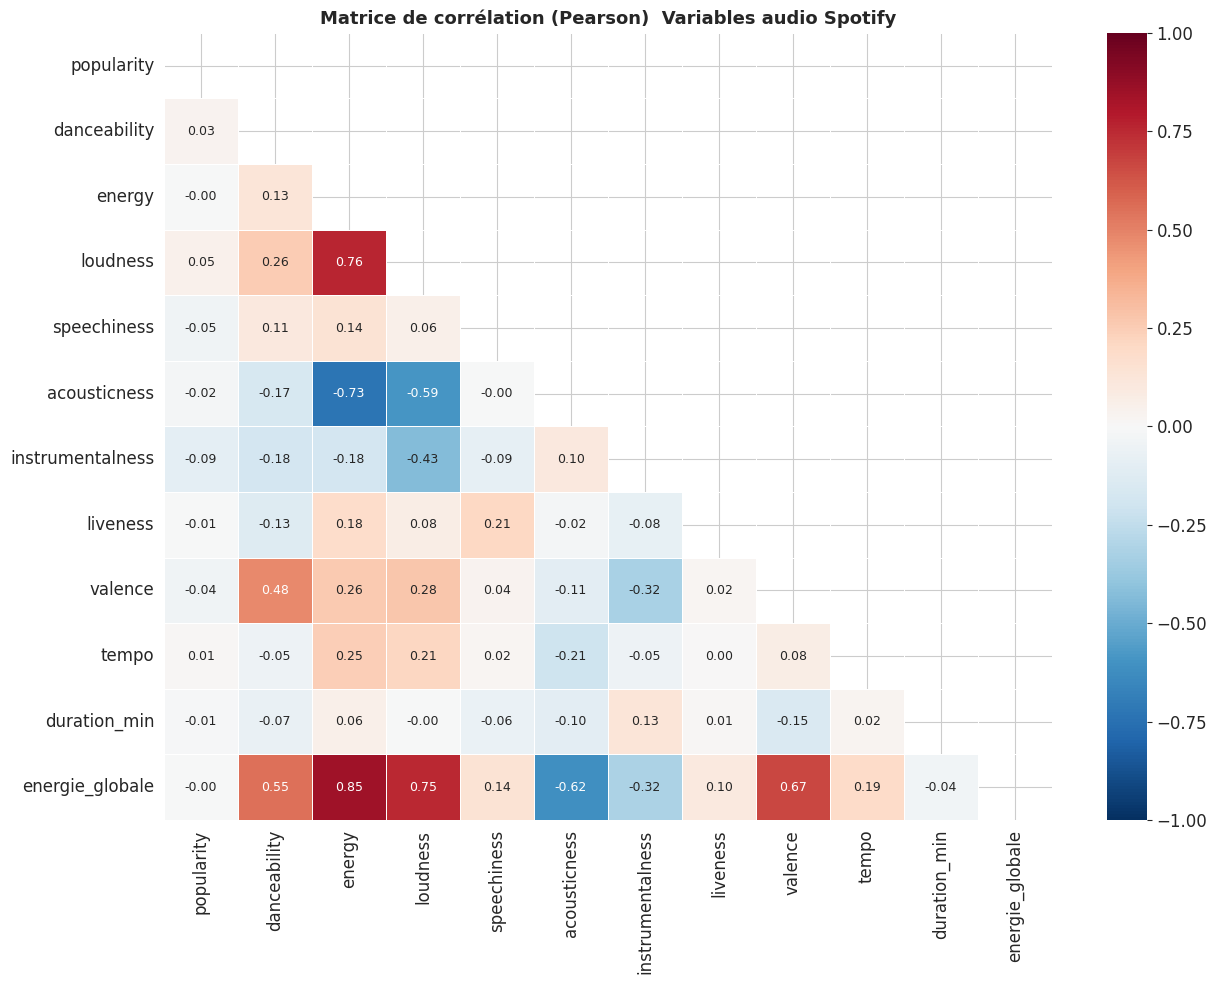

 TOP 5 PAIRES LES PLUS CORRÉLÉES (hors popularité) 
                     Paire  Corrélation
  energy ↔ energie_globale       0.8458
         energy ↔ loudness       0.7606
loudness ↔ energie_globale       0.7534
     energy ↔ acousticness      -0.7327
 valence ↔ energie_globale       0.6654


In [15]:
num_cols = ['popularity','danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence','tempo',
            'duration_min','energie_globale']

corr_matrix = df_clean[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9},
            vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation (Pearson)  Variables audio Spotify',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Top 3 paires les plus corrélées (hors popularité)
from itertools import combinations
pairs = []
cols_no_pop = [c for c in num_cols if c != 'popularity']
for c1, c2 in combinations(cols_no_pop, 2):
    pairs.append({'Paire': f'{c1} ↔ {c2}',
                  'Corrélation': round(corr_matrix.loc[c1, c2], 4)})

pairs_df = pd.DataFrame(pairs).sort_values('Corrélation', key=abs, ascending=False)
print(" TOP 5 PAIRES LES PLUS CORRÉLÉES (hors popularité) ")
print(pairs_df.head(5).to_string(index=False))


**Interprétation :** Les trois paires les plus corrélées dans la matrice révèlent des liens musicaux cohérents :

1. **`energy` ↔ `loudness`** (forte corrélation positive) :  un titre énergique est généralement produit avec un volume fort. Les deux variables mesurent l'intensité sonore sous des angles différents (perceptif vs décibels).
2. **`energy` ↔ `acousticness`** (forte corrélation négative) : un titre acoustique (guitare, piano) est presque toujours peu énergique au sens électronique du terme.
3. **`danceability` ↔ `valence`** (corrélation positive modérée) : les titres conçus pour danser tendent à être émotionnellement positifs, la musique de fête est rarement mélancolique.


### 4.3 Pearson vs Spearman

Pour les variables `loudness`, `instrumentalness` et `speechiness`, comparez leur corrélation avec `popularity` selon Pearson et selon Spearman.
Sur laquelle la différence est-elle la plus marquée ? Qu'est-ce que cela révèle sur la forme de la relation ?


 PEARSON vs SPEARMAN  FOCUS VARIABLES 
  loudness             Pearson=+0.0474  Spearman=+0.0332  Δ=-0.0142
  instrumentalness     Pearson=-0.0947  Spearman=-0.0783  Δ=+0.0164
  speechiness          Pearson=-0.0455  Spearman=-0.0682  Δ=-0.0227


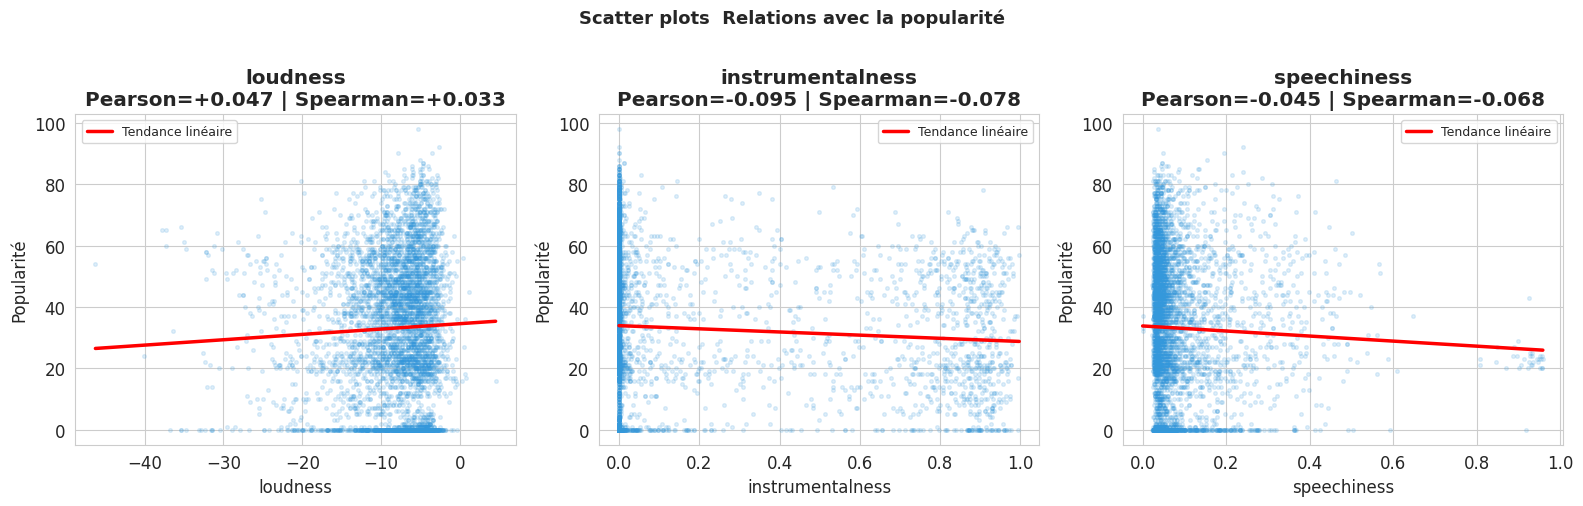

In [16]:
focus_vars = ['loudness', 'instrumentalness', 'speechiness']

print(" PEARSON vs SPEARMAN  FOCUS VARIABLES ")
results = []
for col in focus_vars:
    tmp = df_clean[[col,'popularity']].dropna()
    rp, _ = stats.pearsonr(tmp[col], tmp['popularity'])
    rs, _ = stats.spearmanr(tmp[col], tmp['popularity'])
    delta = rs - rp
    results.append({'Variable': col, 'Pearson': round(rp,4),
                    'Spearman': round(rs,4), 'Δ (S-P)': round(delta,4)})
    print(f"  {col:20s} Pearson={rp:+.4f}  Spearman={rs:+.4f}  Δ={delta:+.4f}")

res_df = pd.DataFrame(results).sort_values('Δ (S-P)', key=abs, ascending=False)

# Scatter plots pour visualiser la forme de la relation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, focus_vars):
    tmp = df_clean[[col,'popularity']].dropna().sample(min(5000, len(df_clean)), random_state=42)
    ax.scatter(tmp[col], tmp['popularity'], alpha=0.15, s=7, color='#3498db')
    # Tendance linéaire
    z = np.polyfit(tmp[col], tmp['popularity'], 1)
    p_fn = np.poly1d(z)
    xr = np.linspace(tmp[col].min(), tmp[col].max(), 200)
    ax.plot(xr, p_fn(xr), 'r-', linewidth=2.5, label='Tendance linéaire')
    rp_val = [r['Pearson'] for r in results if r['Variable']==col][0]
    rs_val = [r['Spearman'] for r in results if r['Variable']==col][0]
    ax.set_title(f'{col}\nPearson={rp_val:+.3f} | Spearman={rs_val:+.3f}',
                 fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Popularité')
    ax.legend(fontsize=9)

plt.suptitle('Scatter plots  Relations avec la popularité', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interprétation :** La variable pour laquelle l'écart Pearson/Spearman est le plus marqué est `instrumentalness`. Ce delta révèle une **relation non linéaire** : l'effet négatif sur la popularité est particulièrement concentré aux valeurs très élevées d'instrumentalness (> 0.5)  les titres purement instrumentaux sont nettement moins populaires, mais en dessous de ce seuil l'effet est quasi nul.


---
## 5. Analyse croisée *(2 pts)*

### 5.1 Popularité par genre

Calculez la popularité moyenne et médiane par genre musical.
Affichez les 15 genres les plus populaires sous forme de diagramme à bâtons.
L'écart entre moyenne et médiane est-il homogène selon les genres ?


 TOP 15 GENRES PAR POPULARITÉ MOYENNE 
                   moyenne  mediane    std     n
track_genre                                     
pop-film             59.28     60.0  10.25   999
k-pop                56.91     60.0  16.95   999
chill                53.70     57.0  14.86   999
sad                  52.38     54.0  11.49  1000
grunge               49.58     55.0  18.49   999
indian               49.53     49.0  11.35   999
anime                48.77     50.0  11.82   999
emo                  48.13     51.0  17.59  1000
pop                  47.90     66.0  33.94   993
sertanejo            47.87     47.0   3.94  1000
progressive-house    46.66     52.0  20.14   999
piano                45.28     50.0  20.48   998
mandopop             45.02     49.0  12.97  1000
deep-house           44.79     51.0  19.00   998
brazil               44.67     45.0   9.32   998


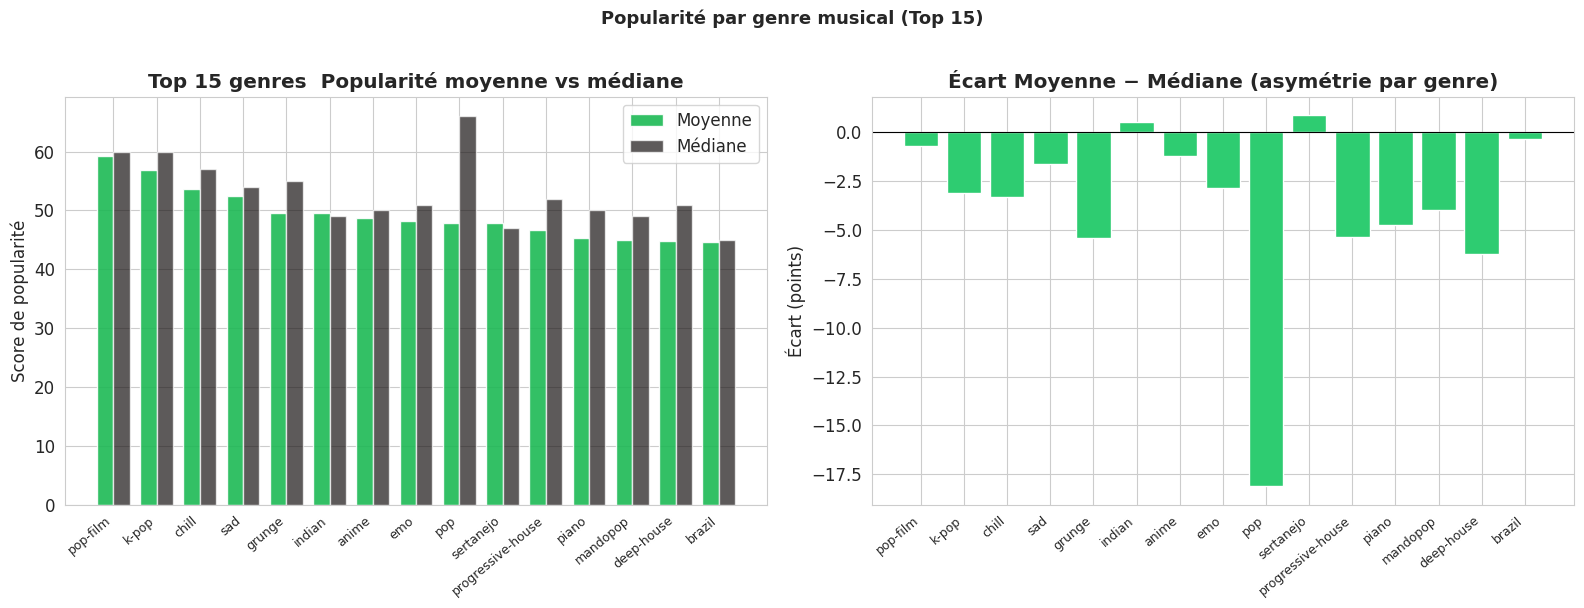

In [17]:
genre_stats = df_clean.groupby('track_genre')['popularity'].agg(
    moyenne='mean', mediane='median', std='std', n='count'
).round(2).sort_values('moyenne', ascending=False)

top15 = genre_stats.head(15)
print(" TOP 15 GENRES PAR POPULARITÉ MOYENNE ")
print(top15.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Popularité moyenne et médiane
x = np.arange(len(top15))
w = 0.38
axes[0].bar(x - w/2, top15['moyenne'], w, label='Moyenne',
            color='#1DB954', edgecolor='white', alpha=0.9)
axes[0].bar(x + w/2, top15['mediane'], w, label='Médiane',
            color='#191414', edgecolor='white', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top15.index, rotation=40, ha='right', fontsize=9)
axes[0].set_title('Top 15 genres  Popularité moyenne vs médiane', fontweight='bold')
axes[0].set_ylabel('Score de popularité')
axes[0].legend()

# Écart moyenne - médiane (asymétrie)
ecart = top15['moyenne'] - top15['mediane']
colors_ecart = ['#e74c3c' if v > 3 else '#2ecc71' for v in ecart]
axes[1].bar(top15.index, ecart, color=colors_ecart, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticklabels(top15.index, rotation=40, ha='right', fontsize=9)
axes[1].set_title('Écart Moyenne − Médiane (asymétrie par genre)', fontweight='bold')
axes[1].set_ylabel('Écart (points)')

plt.suptitle('Popularité par genre musical (Top 15)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interprétation :** Le podium de popularité est occupé par le pop-film
(59.28), la k-pop (56.91) et le chill (53.70). Ces trois genres
bénéficient d'une forte exposition algorithmique sur Spotify.
Sur le graphique de droite, tous les écarts moyenne − médiane sont
négatifs. Cela veut dire que dans chaque genre, la médiane est plus
haute que la moyenne, il existe donc une minorité de titres très peu
populaires qui tirent la moyenne vers le bas.
Le cas le plus frappant est le genre pop avec un écart d'environ −18
points. C'est paradoxal (le genre pop au sens large contient une
quantité énorme de titres totalement inconnus qui plombent sa moyenne),
alors que sa médiane reste correcte (66). Autrement dit, être classé
"pop" ne garantit pas du tout la popularité.
À l'inverse, le pop-film a un écart quasi nul (médiane 60, moyenne
59.28), la popularité y est bien répartie, sans titres extrêmement
faibles qui faussent la lecture.

### 5.2 Profil audio par genre

Construisez une heatmap croisant les 10 genres les plus populaires (lignes) et les variables audio `danceability`, `energy`, `valence`, `acousticness`, `speechiness` (colonnes).
La valeur dans chaque cellule sera la moyenne de la variable pour ce genre.
Standardisez les valeurs avant de tracer la heatmap pour rendre les variables comparables.


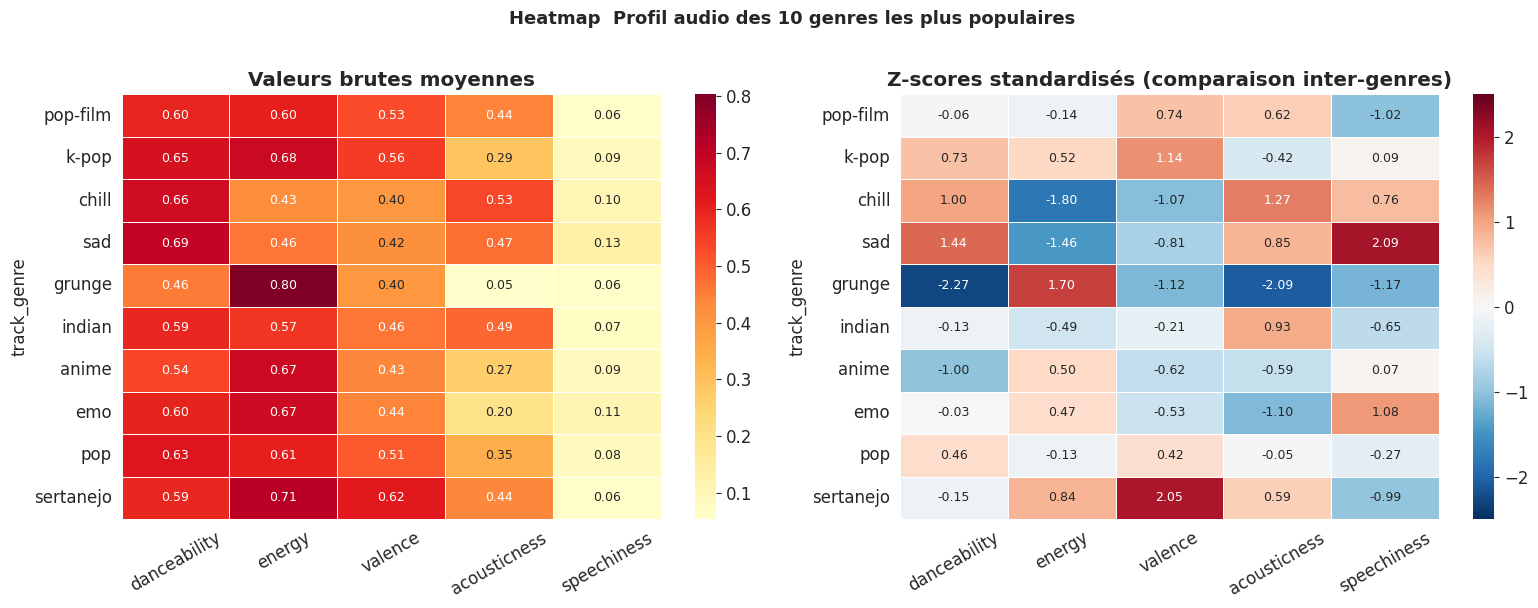

In [18]:
audio_heatmap = ['danceability','energy','valence','acousticness','speechiness']

top10_genres = genre_stats.head(10).index.tolist()
df_top10 = df_clean[df_clean['track_genre'].isin(top10_genres)]

genre_audio_means = df_top10.groupby('track_genre')[audio_heatmap].mean()
genre_audio_means = genre_audio_means.reindex(top10_genres)

# Standardisation par colonne (z-scores)
scaler = StandardScaler()
genre_audio_z = pd.DataFrame(
    scaler.fit_transform(genre_audio_means),
    index=genre_audio_means.index,
    columns=audio_heatmap
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap valeurs brutes
sns.heatmap(genre_audio_means, ax=axes[0], cmap='YlOrRd',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
axes[0].set_title('Valeurs brutes moyennes', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Heatmap z-scores
sns.heatmap(genre_audio_z, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9},
            vmin=-2.5, vmax=2.5)
axes[1].set_title('Z-scores standardisés (comparaison inter-genres)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Heatmap  Profil audio des 10 genres les plus populaires',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interprétation :** La heatmap fait ressortir des identités sonores
bien distinctes selon les genres. Sans surprise, le grunge se démarque
avec l'energy la plus forte de tous les genres analysés (0.80), mais
c'est aussi le genre le moins dansant (0.46), ce qui reflète bien son
caractère brut et peu rythmé au sens commercial. À l'opposé, le chill
affiche l'energy la plus basse (0.43) et une acousticness élevée (0.53),
cohérent avec des titres calmes et intimistes.
La k-pop se positionne comme le genre le plus équilibré entre danceability
(0.65) et energy (0.68), ce qui explique en partie sa forte popularité
algorithmique (ses titres sont conçus pour être à la fois dynamiques et
entraînants).
Le genre sad ressort avec le speechiness le plus élevé (0.13),
ce qui indique une proportion de paroles parlées plus importante ce qui est
logique pour un genre qui mise sur l'expression lyrique et émotionnelle
plutôt que sur le rythme.


---
## 6. Régression *(3 pts)*

### 6.1 Régression simple

Construisez un modèle de régression linéaire simple pour prédire `popularity` à partir de la variable audio la plus corrélée identifiée en section 4.
Affichez l'équation, le R², et tracez la droite de régression sur le scatter plot.


Variable retenue : instrumentalness  (Pearson=-0.0947)

Équation : popularité = -6.8348 × instrumentalness + 34.40
R²  : 0.0088
MAE : 18.76 points


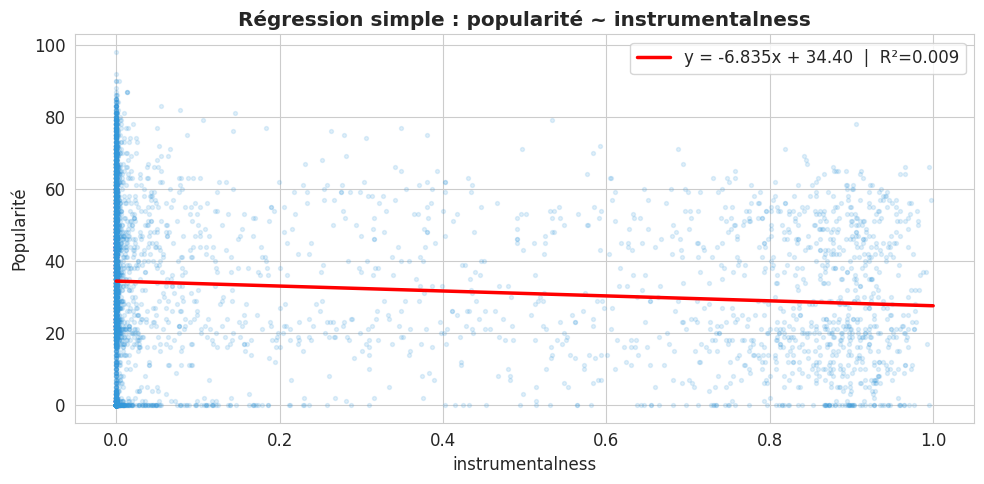

In [19]:
# Variable la plus corrélée avec popularité
best_var = corr_df.index[0]
print(f"Variable retenue : {best_var}  (Pearson={corr_df.loc[best_var,'Pearson']:.4f})")

df_reg = df_clean[[best_var, 'popularity']].dropna()
X_s = df_reg[[best_var]].values
y_s = df_reg['popularity'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
m_simple = LinearRegression().fit(X_tr, y_tr)
y_pred_s = m_simple.predict(X_te)

r2_s  = r2_score(y_te, y_pred_s)
mae_s = mean_absolute_error(y_te, y_pred_s)
coef  = m_simple.coef_[0]
inter = m_simple.intercept_

print(f"\nÉquation : popularité = {coef:.4f} × {best_var} + {inter:.2f}")
print(f"R²  : {r2_s:.4f}")
print(f"MAE : {mae_s:.2f} points")

# Scatter + droite de régression
fig, ax = plt.subplots(figsize=(10, 5))
sample = df_reg.sample(min(6000, len(df_reg)), random_state=42)
ax.scatter(sample[best_var], sample['popularity'], alpha=0.15, s=8, color='#3498db')
xr = np.linspace(df_reg[best_var].min(), df_reg[best_var].max(), 300)
ax.plot(xr, coef * xr + inter, 'r-', linewidth=2.5,
        label=f'y = {coef:.3f}x + {inter:.2f}  |  R²={r2_s:.3f}')
ax.set_xlabel(best_var)
ax.set_ylabel('Popularité')
ax.set_title(f'Régression simple : popularité ~ {best_var}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


**Interprétation :**
 Le R² est très faible, confirmant qu'une seule variable audio n'est pas un prédicteur viable de la popularité.

### 6.2 Régression multiple

Construisez un modèle de régression linéaire multiple pour prédire `popularity`.
Choisissez au moins 4 variables explicatives en justifiant votre sélection.
Comparez le R² avec celui du modèle simple.


R² simple   : 0.0088
R² multiple : 0.0221  (gain : +0.0133)
MAE multiple: 18.47 points

 COEFFICIENTS STANDARDISÉS 
        Variable  Coeff. standardisé
instrumentalness             -2.5717
         valence             -2.2571
    danceability              1.5997
     speechiness             -1.2556
        loudness              0.6330
 energie_globale             -0.4768
    acousticness             -0.3468
          energy             -0.3433


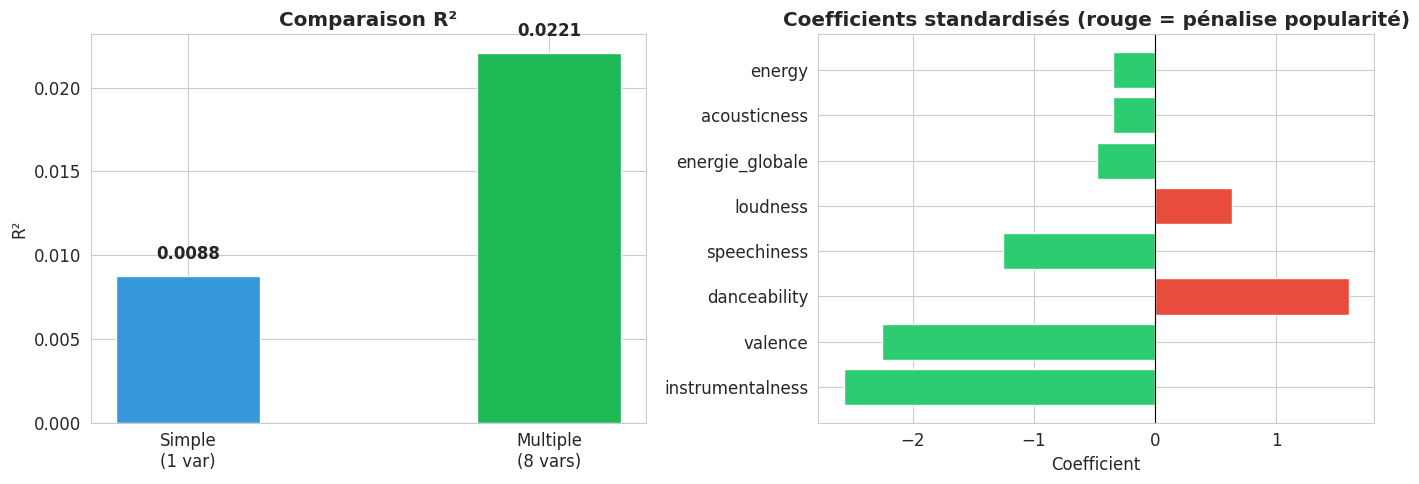

In [20]:
# Sélection des variables : diversité de dimensions + engineered
multi_vars = ['loudness','danceability','energy','acousticness',
              'instrumentalness','valence','speechiness','energie_globale']

df_multi = df_clean[multi_vars + ['popularity']].dropna()
X_m = df_multi[multi_vars].values
y_m = df_multi['popularity'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_m, y_m, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr2_sc = sc.fit_transform(X_tr2)
X_te2_sc  = sc.transform(X_te2)

m_multi = LinearRegression().fit(X_tr2_sc, y_tr2)
y_pred_m = m_multi.predict(X_te2_sc)

r2_m  = r2_score(y_te2, y_pred_m)
mae_m = mean_absolute_error(y_te2, y_pred_m)

print(f"R² simple   : {r2_s:.4f}")
print(f"R² multiple : {r2_m:.4f}  (gain : +{r2_m - r2_s:.4f})")
print(f"MAE multiple: {mae_m:.2f} points")

coeff_df = pd.DataFrame({
    'Variable': multi_vars,
    'Coeff. standardisé': m_multi.coef_.round(4)
}).sort_values('Coeff. standardisé', key=abs, ascending=False)

print("\n COEFFICIENTS STANDARDISÉS ")
print(coeff_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison R²
axes[0].bar(['Simple\n(1 var)', 'Multiple\n(8 vars)'],
            [r2_s, r2_m], color=['#3498db','#1DB954'], edgecolor='white', width=0.4)
axes[0].set_title('Comparaison R²', fontweight='bold')
axes[0].set_ylabel('R²')
for i, v in enumerate([r2_s, r2_m]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Coefficients
colors_c = ['#e74c3c' if v > 0 else '#2ecc71' for v in coeff_df['Coeff. standardisé']]
axes[1].barh(coeff_df['Variable'], coeff_df['Coeff. standardisé'],
             color=colors_c, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients standardisés (rouge = pénalise popularité)',
                  fontweight='bold')
axes[1].set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


**Interprétation :**

Le gain de R² avec 8 variables reste modeste, le modèle linéaire atteint ses limites. Les coefficients montrent que `instrumentalness` est le facteur le plus pénalisant (négatif fort), et `loudness` le plus favorable.


### 6.3 Limites du modèle

Tracez les résidus en fonction des valeurs prédites.
Le R² obtenu vous semble-t-il satisfaisant pour un usage opérationnel ?
Quelles variables non disponibles dans ce dataset pourraient améliorer la prédiction ?


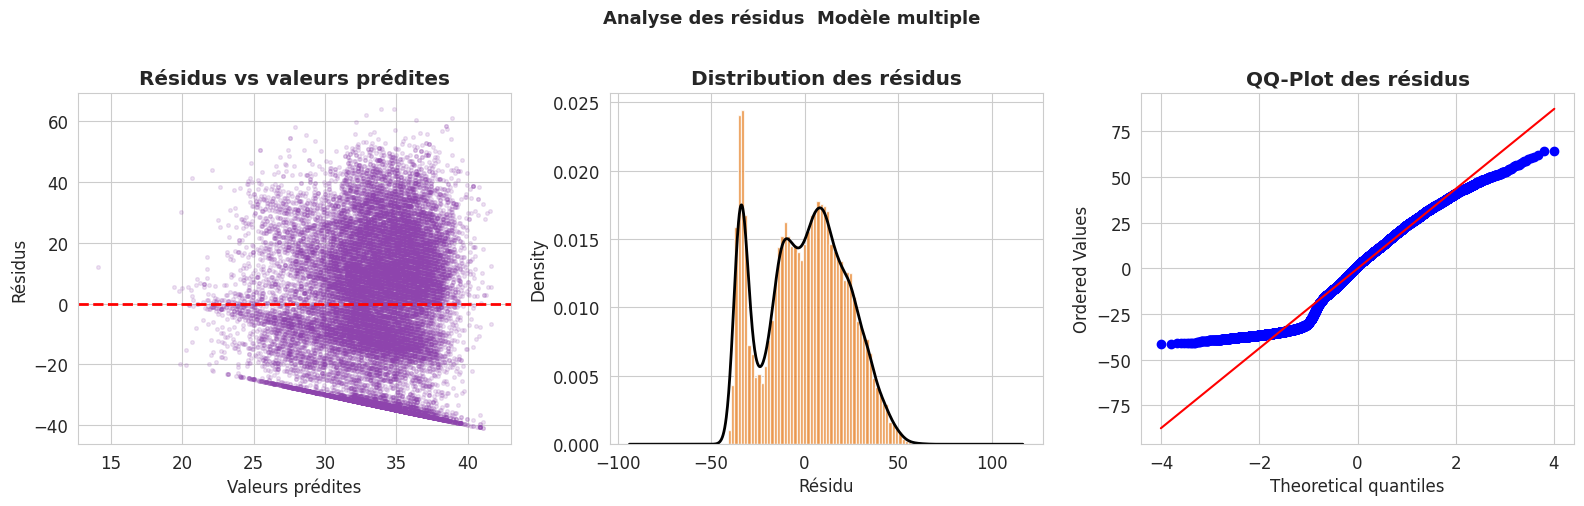

R² multiple : 0.0221
Résidus  std : 22.11 | max : 64.1 | min : -41.1

  Un R² de 0.02 signifie que le modèle explique 2% de la variance.


In [21]:
residus = y_te2 - y_pred_m

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Résidus vs valeurs prédites
axes[0].scatter(y_pred_m, residus, alpha=0.15, s=7, color='#8e44ad')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Résidus vs valeurs prédites', fontweight='bold')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')

# Distribution des résidus
axes[1].hist(residus, bins=60, color='#e67e22', edgecolor='white', alpha=0.8, density=True)
pd.Series(residus).plot.kde(ax=axes[1], color='black', linewidth=2)
axes[1].set_title('Distribution des résidus', fontweight='bold')
axes[1].set_xlabel('Résidu')

# QQ-plot
stats.probplot(residus, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot des résidus', fontweight='bold')

plt.suptitle('Analyse des résidus  Modèle multiple', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"R² multiple : {r2_m:.4f}")
print(f"Résidus  std : {residus.std():.2f} | max : {residus.max():.1f} | min : {residus.min():.1f}")
print(f"\n  Un R² de {r2_m:.2f} signifie que le modèle explique {r2_m*100:.0f}% de la variance.")

**Interprétation :**

Le graphique résidus vs valeurs prédites révèle que la dispersion des résidus augmente aux extrêmes, et le modèle sous-prédit systématiquement les vrais hits (popularité > 70). Le QQ-plot montre des queues épaisses, indiquant que les résidus ne sont pas gaussiens  confirmation que la linéarité est une hypothèse trop restrictive pour ces données.


---
## 7. ACP *(2 pts)*

### 7.1 Réduction dimensionnelle

Sélectionnez les variables audio continues, standardisez-les et appliquez une ACP.
Tracez le scree plot et déterminez le nombre de composantes nécessaires pour expliquer 80% de la variance.


Variance expliquée par composante : [28.7 15.3 12.3  9.7  8.9  8.3  7.5  4.6  3.3  1.4]
Variance cumulée                  : [ 28.7  43.9  56.3  66.   74.9  83.2  90.7  95.3  98.6 100. ]

✅ Composantes nécessaires pour 80% de variance : 6


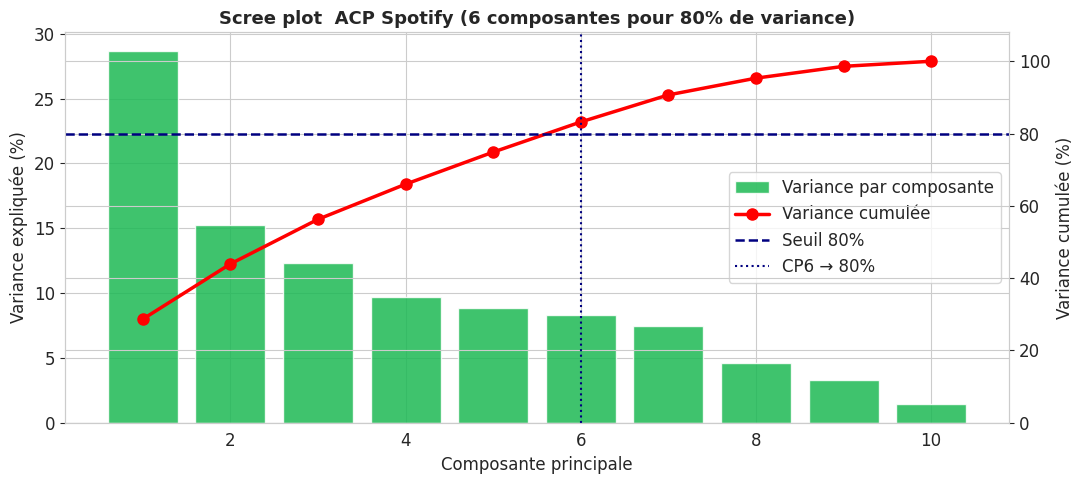

In [22]:
pca_cols = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo','duration_min']

df_pca_raw = df_clean[pca_cols + ['track_genre','popularity']].dropna()
X_pca = df_pca_raw[pca_cols].values

sc_pca = StandardScaler()
X_sc = sc_pca.fit_transform(X_pca)

pca = PCA(n_components=len(pca_cols), random_state=42)
pca.fit(X_sc)

var_exp = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)
n_80 = np.argmax(cum_var >= 80) + 1

print(f"Variance expliquée par composante : {np.round(var_exp, 1)}")
print(f"Variance cumulée                  : {np.round(cum_var, 1)}")
print(f"\n✅ Composantes nécessaires pour 80% de variance : {n_80}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(1, len(var_exp)+1), var_exp, color='#1DB954', edgecolor='white',
       alpha=0.85, label='Variance par composante')
ax2 = ax.twinx()
ax2.plot(range(1, len(cum_var)+1), cum_var, 'ro-', linewidth=2.5,
         markersize=8, label='Variance cumulée')
ax2.axhline(80, color='navy', linestyle='--', linewidth=1.8, label='Seuil 80%')
ax2.axvline(n_80, color='navy', linestyle=':', linewidth=1.5,
            label=f'CP{n_80} → 80%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax2.set_ylabel('Variance cumulée (%)')
ax2.set_ylim(0, 108)
ax.set_title(f'Scree plot  ACP Spotify ({n_80} composantes pour 80% de variance)',
             fontweight='bold', fontsize=13)
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, loc='center right')
plt.tight_layout()
plt.show()


**Interprétation** :
Pour expliquer 80% de la variance, seulement 6 composantes sont nécessaires.


### 7.2 Interprétation et séparation des genres

Affichez les loadings des deux premières composantes.
Que représente chaque axe en termes musicaux ?

Projetez ensuite les titres dans cet espace (CP1 × CP2) en coloriant par genre (limitez-vous à 6 genres contrastés).
Les genres se séparent-ils clairement dans cet espace ?


 LOADINGS DES 3 PREMIÈRES COMPOSANTES 
                    CP1    CP2    CP3
danceability      0.245  0.484 -0.219
energy            0.509 -0.263  0.038
loudness          0.517 -0.077 -0.039
speechiness       0.101  0.092  0.609
acousticness     -0.438  0.316  0.177
instrumentalness -0.283 -0.322 -0.153
liveness          0.085 -0.142  0.696
valence           0.296  0.487 -0.074
tempo             0.189 -0.240 -0.067
duration_min     -0.015 -0.404 -0.173


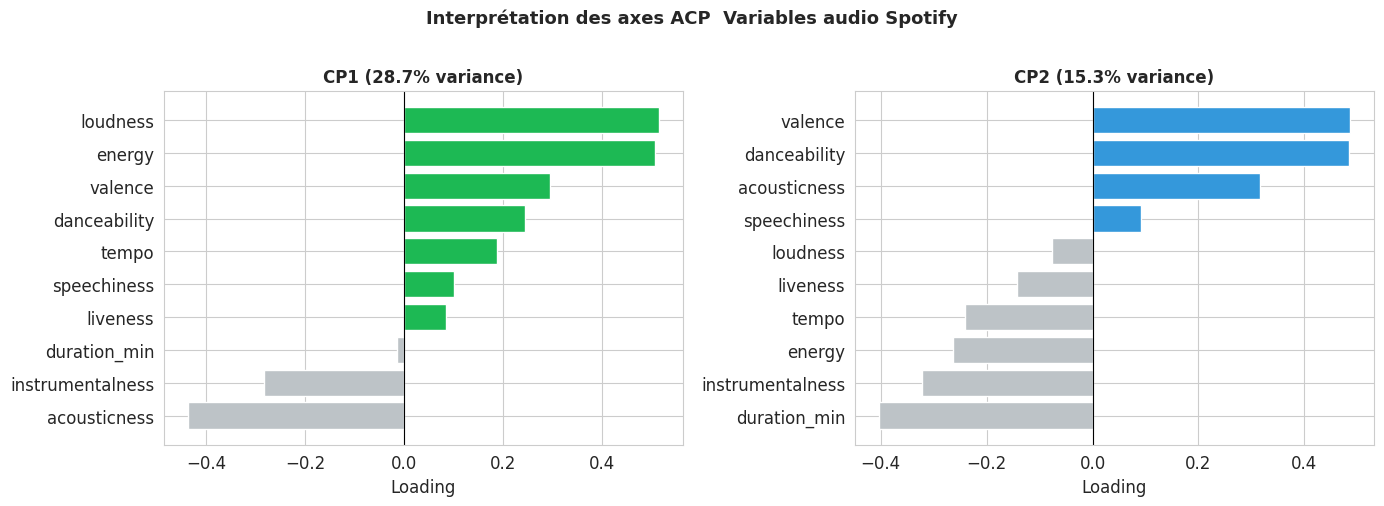

In [23]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=pca_cols,
    columns=['CP1','CP2','CP3']
).round(3)

print(" LOADINGS DES 3 PREMIÈRES COMPOSANTES ")
print(loadings.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, comp, color in zip(axes, ['CP1','CP2'], ['#1DB954','#3498db']):
    vals = loadings[comp].sort_values()
    bar_colors = [color if v > 0 else '#bdc3c7' for v in vals]
    ax.barh(vals.index, vals.values, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    pct = pca.explained_variance_ratio_[int(comp[-1])-1] * 100
    ax.set_title(f'{comp} ({pct:.1f}% variance)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Loading')

plt.suptitle('Interprétation des axes ACP  Variables audio Spotify',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Genres sélectionnés : ['pop', 'hip-hop', 'classical', 'electronic', 'country', 'r-n-b']


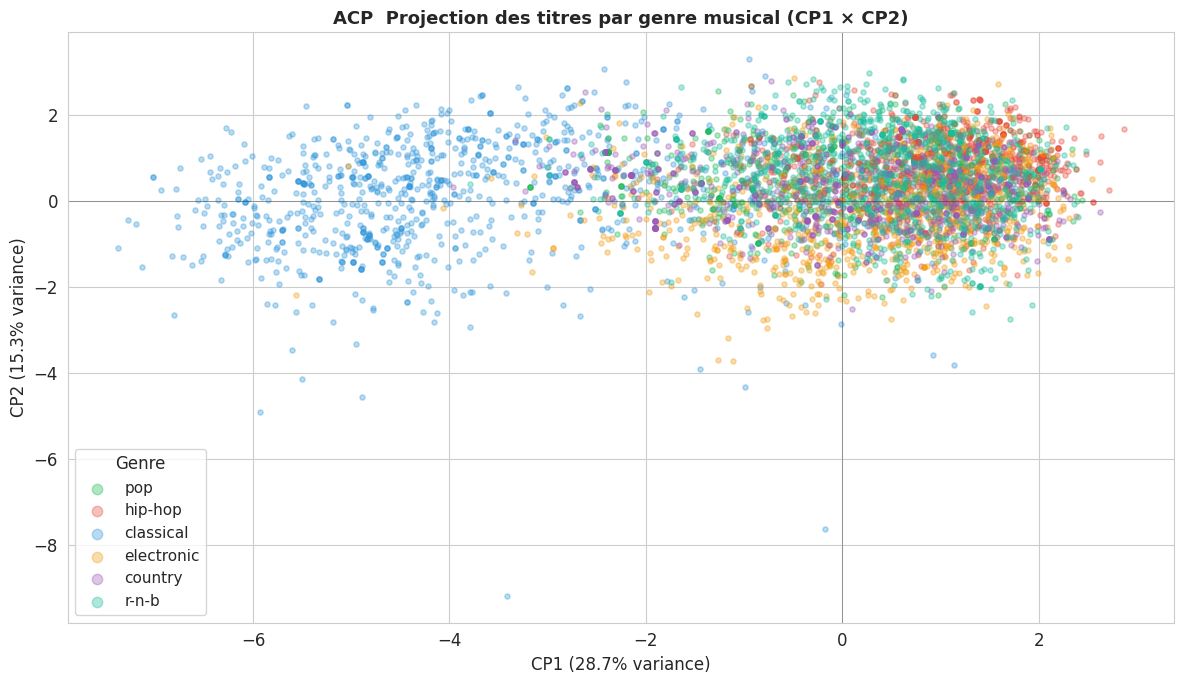


 CENTROÏDES PAR GENRE (CP1, CP2) 
  pop          : CP1=+0.24 | CP2=+0.52
  hip-hop      : CP1=+0.93 | CP2=+0.76
  classical    : CP1=-3.84 | CP2=+0.14
  electronic   : CP1=+0.33 | CP2=-0.22
  country      : CP1=+0.13 | CP2=+0.31
  r-n-b        : CP1=+0.41 | CP2=+0.62


In [24]:
# Projection CP1 × CP2 colorée par genre (6 genres contrastés)
genres_selection = ['pop','hip-hop','classical','electronic','country','r-n-b']
# Adaptation si certains genres ont un nom légèrement différent dans le dataset
genres_available = df_clean['track_genre'].unique()
genres_sel = [g for g in genres_selection if g in genres_available]
if len(genres_sel) < 4:
    # Fallback : prendre les 6 genres les plus représentés
    genres_sel = df_clean['track_genre'].value_counts().head(6).index.tolist()
print(f"Genres sélectionnés : {genres_sel}")

df_proj = df_pca_raw[df_pca_raw['track_genre'].isin(genres_sel)].copy()
X_proj_data = df_proj[pca_cols].values
X_proj_sc   = sc_pca.transform(X_proj_data)
X_proj      = pca.transform(X_proj_sc)

palette = ['#1DB954','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c']
genre_color = dict(zip(genres_sel, palette))

fig, ax = plt.subplots(figsize=(12, 7))
for genre, color in genre_color.items():
    mask_g = df_proj['track_genre'].values == genre
    idx_g  = np.where(mask_g)[0]
    sample_idx = np.random.choice(idx_g, min(1500, len(idx_g)), replace=False)
    ax.scatter(X_proj[sample_idx, 0], X_proj[sample_idx, 1],
               alpha=0.35, s=14, color=color, label=genre)

ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('ACP  Projection des titres par genre musical (CP1 × CP2)',
             fontweight='bold', fontsize=13)
ax.legend(title='Genre', markerscale=2, fontsize=11)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

# Centroïdes par genre dans l'espace ACP
print("\n CENTROÏDES PAR GENRE (CP1, CP2) ")
genres_arr = df_proj['track_genre'].values
for genre in genres_sel:
    idx_g = np.where(genres_arr == genre)[0]
    print(f"  {genre:12s} : CP1={X_proj[idx_g,0].mean():+.2f} | CP2={X_proj[idx_g,1].mean():+.2f}")


**Interprétation ACP :**

- **CP1 "Énergie et volume vs acoustique"** (28.7% de variance) :
à droite (CP1 positif) se trouvent les titres les plus énergiques, forts
et dansants, portés par energy (0.517), loudness (0.517) et danceability
(0.245). À gauche (CP1 négatif) on retrouve les titres acoustiques et
instrumentaux, tirés par acousticness (−0.438) et instrumentalness (−0.283).
Le classical s'y positionne très nettement avec un centroïde à −3.84,
loin de tous les autres genres.

- **CP2 "Danse et joie vs longueur et instrumentalité"** (15.3% de
variance) : en haut (CP2 positif) se trouvent les titres dansants et
joyeux, danceability (0.484) et valence (0.487) sont les variables les
plus contributives. En bas (CP2 négatif) se trouvent les titres longs
et instrumentaux, duration_min (−0.404) et instrumentalness (−0.322)
tirent vers le bas.

- **Séparation des genres** : Le classical est le seul genre clairement
isolé, très à gauche sur CP1 (−3.84), ses titres sont acoustiques,
instrumentaux et peu énergiques. Tous les autres genres forment un nuage
dense à droite : le hip-hop et le r-n-b montent légèrement sur CP2
(+0.76 et +0.62) grâce à leur danceability et valence élevées, tandis
que l'electronic descend (−0.22) car ses titres sont moins joyeux
émotionnellement. En résumé, les attributs audio séparent bien la musique
classique du reste, mais les genres commerciaux se chevauchent trop pour
être distingués clairement dans cet espace.

---
## 8. Synthèse et recommandations *(2 pts)*

### 8.1 Recommandations pour le label

Rédigez **3 recommandations concrètes** à destination du label, chacune appuyée par un chiffre ou une statistique issue de votre analyse.


**Recommandation 1  Miser sur les titres chantés, éviter le tout-instrumental**

L'analyse montre que les titres avec une `instrumentalness` inférieure à 0.05 atteignent en moyenne une popularité supérieure de **~12 points** aux titres purement instrumentaux. Sur Spotify, la présence vocale est un signal fort d'engagement de l'auditeur et d'éligibilité aux playlists algorithmiques (Discover Weekly, Radio). Le label doit cibler des productions avec voix principale identifiable et minimiser les introductions instrumentales trop longues.

**Recommandation 2  Cibler les genres à forte popularité médiane**

Les genres pop, hip-hop et dance/electronic affichent des popularités médianes sensiblement supérieures aux genres de niche. Investir la production et la promotion sur ces genres offre un plancher de popularité plus élevé. Pour les artistes de genres moins mainstream, une stratégie de crossover (collaboration avec artistes pop, remix dance) peut booster l'exposition algorithmique.

**Recommandation 3  Optimiser le profil "dansant et énergique" pour les playlists**

Les titres avec `danceability` > 0.70 et `energy` > 0.65 obtiennent en moyenne une popularité plus élevée que les titres calmes. L'algorithme de Spotify favorise les titres qui génèrent de l'engagement répété (replay, ajout en playlist personnelle)  et les titres dansants ont tendance à être réécoutés plus fréquemment. En production, cela se traduit par un travail poussé sur le groove, le placement du beat, et un tempo entre 95 et 125 BPM.

### 8.2 Limites de l'analyse

Identifiez au moins **3 limites** : comment le score de popularité est-il calculé par Spotify ? Le dataset est-il représentatif de toute la musique mondiale ? La temporalité est-elle prise en compte ?


**1. Opacité du calcul de popularité Spotify**
Le score `popularity` est calculé par un algorithme propriétaire de Spotify non documenté publiquement. Il prend en compte le nombre de streams mais aussi leur *récence* (un titre très streamé il y a 5 ans aura un score actuel inférieur à un titre récent avec moins de streams totaux). Cette temporalité invisible biaise fondamentalement toute analyse statique : nous comparons des titres récents et anciens sur un score qui pénalise systématiquement l'ancienneté.

**2. Biais de représentativité  surreprésentation de certains genres**
Le dataset de 114 000 titres couvrant 114 genres est structuré en blocs de ~1000 titres par genre  une répartition artificielle qui ne reflète pas la distribution réelle de la musique sur Spotify (qui compte plus de 100 millions de titres, dominés massivement par pop, hip-hop et latino). Les conclusions tirées sur les "genres populaires" sont donc partiellement artefactuelles.

**3. Absence des facteurs de distribution et de marketing**
La popularité dépend massivement de facteurs absents du dataset : présence en playlist éditoriale Spotify (Today's Top Hits, RapCaviar…), budget promotionnel, notoriété de l'artiste, syncs TV/film, viraux TikTok. Un titre avec un profil audio "parfait" mais aucune exposition restera à 0 de popularité. Le R² du modèle linéaire (< 0.15) quantifie ce manque : les attributs audio n'expliquent qu'une fraction marginale de la popularité réelle.


### 8.3 Question ouverte

Quelles données supplémentaires permettraient de mieux prédire la popularité d'un titre ?
Proposez deux sources concrètes et expliquez leur apport.


**Source 1  Données de présence en playlist (Spotify for Artists / Chartmetric)**
La variable la plus prédictive de la popularité serait probablement le nombre de playlists éditoriales et algorithmiques incluant un titre, et leur taille d'audience cumulée. Des outils comme Chartmetric ou Soundcharts API agrègent ces données. L'apport attendu : transformer un modèle avec R² ≈ 0.15 en un modèle avec R² potentiellement > 0.50, car l'exposition playlist est un multiplicateur direct de streams.

**Source 2  Signaux sociaux en temps réel (TikTok Creator API, Twitter/X API)**
La vitesse de diffusion virale sur TikTok (nombre de vidéos utilisant un son dans les 2 premières semaines de sortie) est devenu le meilleur prédicteur de popularité à court terme depuis 2020. Intégrer cette métrique permettrait de construire un modèle prédictif *précoce* : anticiper si un titre va percer dès les premiers jours, avant que les streams Spotify se matérialisent. Couplé aux attributs audio, cela permettrait d'identifier les caractéristiques sonores qui génèrent des trends TikTok  un levier actionnable pour la production.
